In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


In [ ]:
df = pd.read_csv('height-weight.csv')

In [ ]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

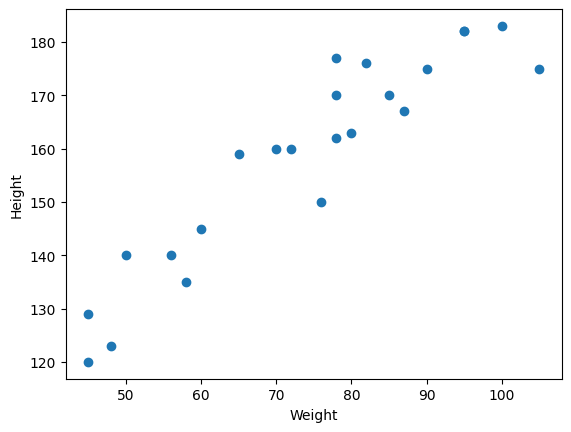

In [ ]:
## scatter
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [ ]:
## correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


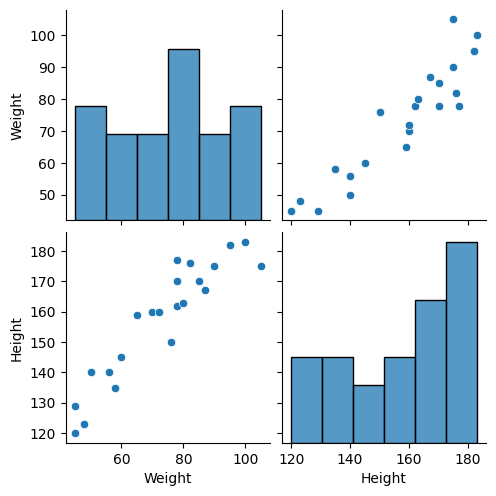

In [ ]:
sns.pairplot(df)

In [ ]:
## independent and dependent features
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [ ]:
X = df[['Weight']]  ## independent features should be data frame
y = df['Height']    ## this variable can be series or 1d array

In [ ]:
X_series = df['Weight']
np.array(X_series).shape


(23,)

In [ ]:
## Trian_Test split
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
X_train.shape

(17, 1)

In [ ]:
## Standardization
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
#

In [ ]:
X_train


array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [ ]:

X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [ ]:
## Applying simple linear regression
from sklearn.linear_model import LinearRegression

In [ ]:
regression = LinearRegression(n_jobs=-1)
regression.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [ ]:
print("Coefficient or slop:", regression.coef_)
print("Intercept:", regression.intercept_)

Coefficient or slop: [17.2982057]
Intercept: 156.47058823529412


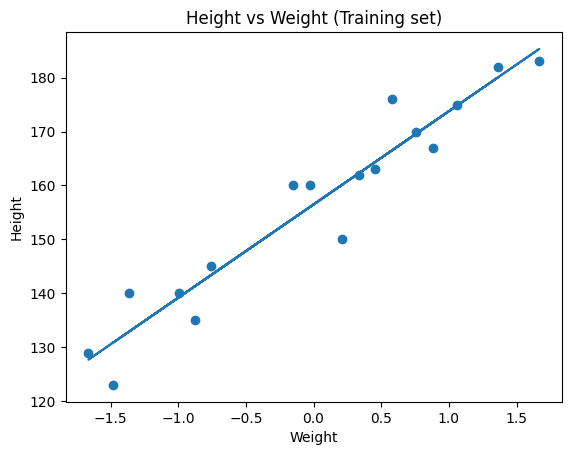

In [ ]:
## plot Training data plot best fit line
plt.scatter(  X_train, y_train)
plt.plot(X_train, regression.predict(X_train))
plt.title('Height vs Weight (Training set)')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()
#

**##prediction of test data**

1.predicted geight output = intercept + coef_(Weight)

2 y_pred_test = 156.470 + 17.29(X_test)

In [ ]:
y_pred =  regression.predict(X_test)

In [ ]:
##Performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)
print("Root Mean Squared Error:", rmse)


Mean Squared Error: 114.84069295228699
Mean Absolute Error: 9.66512588679501
R-squared: 0.7360826717981276
Root Mean Squared Error: 10.716374991212605


Adjusted R2 = 1-[(1.R2)*(n-1)/ **bold text**(n-k-1)] **bold text**

where  

R2 : the R2 of the model n: the number of observations k: the number of predict variables


In [ ]:
1 -(1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.6701033397476595

**OLS Linear Regression**

In [ ]:
import statsmodels.api as sm

In [ ]:
model = sm.OLS(y_train, X_train).fit()
predictions = model.predict(X_train) # make the predictions by the model
print(predictions)

[-15.16409156  28.84875956   5.79440897 -25.64334183  23.60913442
 -28.78711691 -13.06824151  -2.58899124   3.69855892 -23.54749178
 -17.25994162  -0.49314119  18.36950929   9.98610908  13.12988416
  15.22573421   7.89025902]


In [ ]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Fri, 17 Apr 2026   Prob (F-statistic):                       0.664
Time:                        14:07:28   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [ ]:
## prediction for new data
regression.predict(scaler.transform([[72]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])